## Without gene information

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
df=pd.read_csv("../data/csv/calculated_features_bacteria.csv",index_col=0)
df_ogt=pd.read_csv("../data/csv/OGT.csv",index_col=0)
df_ogt = df_ogt[df_ogt["domain"]=="Bacteria"]
l = list(df_ogt[df_ogt["selected"]==True]["species"].values)

In [3]:
df_downsample = df[df["species"].apply(lambda x: x in l)]

In [4]:
df_downsample

,domain,phylum,class,order,family,genus,species,OGT,genome_size,5S_rRNA_A,...,Pro_YM,Pro_YN,Pro_YP,Pro_YQ,Pro_YR,Pro_YS,Pro_YT,Pro_YV,Pro_YW,Pro_YY
0,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Alteromonadaceae,Pseudoalteromonas,pseudoalteromonas distincta,13.750000,4532748,0.285714,...,0.000539,0.001562,0.001307,0.001704,0.001421,0.002395,0.001798,0.001806,0.000430,0.001200
2,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Alcanivoracaceae,Alcanivorax,alcanivorax borkumensis,28.250000,3120143,0.270270,...,0.000542,0.000789,0.001271,0.001481,0.002033,0.001514,0.001286,0.001625,0.000433,0.000674
4,Bacteria,Proteobacteria,Alphaproteobacteria,Rhizobiales_A,Rhizobiaceae_A,Ochrobactrum,ochrobactrum anthropi,27.875000,5205777,0.200000,...,0.000500,0.000765,0.001117,0.000849,0.001738,0.001423,0.001211,0.001733,0.000368,0.000694
5,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Shewanellaceae,Shewanella,shewanella halifaxensis,11.666667,5226917,0.274179,...,0.000595,0.001248,0.001320,0.001980,0.001775,0.002139,0.001515,0.001650,0.000433,0.001027
6,Bacteria,Proteobacteria,Alphaproteobacteria,Rhizobiales,Beijerinckiaceae,Beijerinckia,beijerinckia indica,26.000000,4418616,0.225225,...,0.000359,0.000726,0.001216,0.000856,0.001754,0.001257,0.001134,0.001502,0.000360,0.000687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2864,Bacteria,Thermosulfidibacterota,Thermosulfidibacteria,Thermosulfidibacterales,Thermosulfidibacteraceae,Thermosulfidibacter,thermosulfidibacter takaii,70.000000,1816670,0.225225,...,0.000702,0.001336,0.001919,0.001102,0.002067,0.002062,0.001754,0.002586,0.000464,0.001525
2865,Bacteria,Desulfobacterota_C,Deferrisomatia,Deferrisomatales,Deferrisomataceae,Deferrisoma,deferrisoma camini,50.000000,4236551,0.189189,...,0.000310,0.000427,0.001311,0.000659,0.002561,0.000852,0.001210,0.001755,0.000373,0.000680
2866,Bacteria,Gemmatimonadota,Gemmatimonadetes,Gemmatimonadales,Gemmatimonadaceae,Gemmatimonas,gemmatimonas phototrophica,27.500000,4716552,0.189189,...,0.000366,0.000616,0.001106,0.000742,0.001800,0.001125,0.001420,0.001758,0.000312,0.000559
2867,Bacteria,Caldisericota,Caldisericia,Caldisericales,Caldisericaceae,Caldisericum,caldisericum exile,65.000000,1558103,0.232143,...,0.000592,0.001822,0.001665,0.000707,0.001465,0.002374,0.002026,0.002725,0.000279,0.001703


In [5]:
pred_list=[]
true_list=[]
name_list=[]
cv=1

for phylum in df["phylum"].value_counts().keys()[:]:
    test=df_downsample[df_downsample["phylum"]==phylum]
    if(test.shape[0]==0):
        continue
    train=df_downsample[df_downsample["phylum"]!=phylum]
    c=list(train.columns[8:])
    X_train=np.array(train.loc[:,c].values)
    y_train=np.array(train.loc[:,"OGT"])
    X_test=np.array(test.loc[:,c].values)
    y_test=np.array(test.loc[:,"OGT"])
    
    scaler = preprocessing.MinMaxScaler()
    
    scaler.fit(X_train)
    X_train=scaler.transform(X_train)
    X_test=scaler.transform(X_test)      
    reg = Lasso(alpha=0.004,max_iter=1000,random_state=0).fit(X_train, y_train)
    pred_list.extend(reg.predict(X_test).tolist())
    true_list.extend(y_test.tolist())
    name_list.extend(test["species"].tolist())
    cv+=1

val_score=r2_score(true_list, pred_list)
val_mse=mean_squared_error(true_list, pred_list)
print(val_score)
print(val_mse)

0.8308251587380616
36.158419587410336


<Axes: >

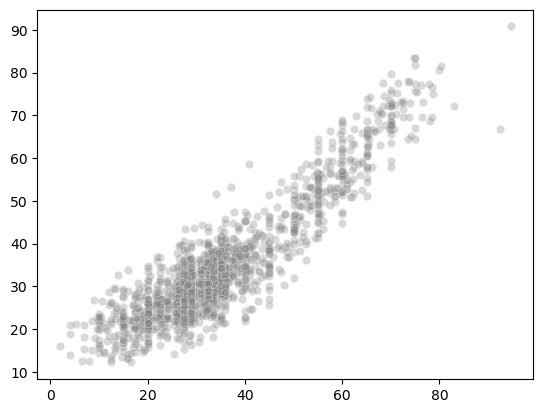

In [6]:
sns.scatterplot(x=true_list, y=pred_list,alpha=0.3,color="gray")

## With gene information

In [7]:
df_gene = pd.read_csv("../data/csv/gene_count.csv",index_col=0)
l = list(df_ogt[df_ogt["selected"]==True]["species"].values)
df_gene_downsample = df_gene[df_gene["species"].apply(lambda x: x in l)]

In [8]:
df_merged = pd.concat((df_downsample,df_gene_downsample.iloc[:,1:]),axis=1)

In [10]:
pred_list2=[]
true_list2=[]
name_list2=[]
cv=1

for phylum in df_merged["phylum"].value_counts().keys()[:]:
    
    df_gene=pd.read_csv("../data/gene_list_without_phylum/method1/gene_"+phylum+".csv")
    df_gene_cold=pd.read_csv("../data/gene_list_without_phylum/method2/gene_"+phylum+"_cold.csv")
    
    l=list(df_gene["ko"].values)[:50]
    l_cold=list(df_gene_cold["ko"].values)[:50]
   
    
    test=df_merged[df_merged["phylum"]==phylum]
    if(test.shape[0]==0):
        continue

    train=df_merged[df_merged["phylum"]!=phylum]
 
    c=list(train.columns[8:534])+list(set(l_cold+l))
    
    X_train=np.array(train.loc[:,c].values)
    y_train=np.array(train.loc[:,"OGT"])
    X_test=np.array(test.loc[:,c].values)
    y_test=np.array(test.loc[:,"OGT"])
    
    scaler = preprocessing.MinMaxScaler()
    scaler.fit(X_train)
    X_train=scaler.transform(X_train)
    X_test=scaler.transform(X_test)   
       
    reg = Lasso(alpha=0.004,max_iter=1000,random_state=0).fit(X_train, y_train)
    pred_list2.extend(reg.predict(X_test).tolist())
    true_list2.extend(y_test.tolist())
    name_list2.extend(test["species"].tolist())
    cv+=1
    #print("done")
val_score2=r2_score(true_list2, pred_list2)
val_mse2=mean_squared_error(true_list2, pred_list2)
print(val_score2) 
print(val_mse)

0.8016962037781638
36.158419587410336


<Axes: >

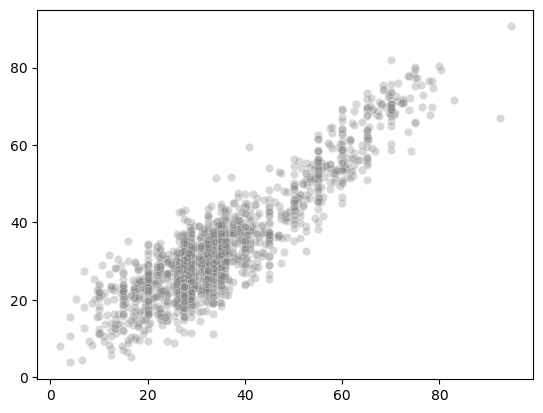

In [11]:
sns.scatterplot(x=true_list2, y=pred_list2,alpha=0.3,color="gray")